# **ML Model**


***Can we predict the crop yield?***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/yield_df.csv')

In [ ]:
df.shape

(28242, 8)

In [ ]:
df.columns

Index(['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield',
       'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp'],
      dtype='object')

In [ ]:
df.head(10)

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37
5,5,Albania,Wheat,1990,30197,1485.0,121.0,16.37
6,6,Albania,Maize,1991,29068,1485.0,121.0,15.36
7,7,Albania,Potatoes,1991,77818,1485.0,121.0,15.36
8,8,Albania,"Rice, paddy",1991,28538,1485.0,121.0,15.36
9,9,Albania,Sorghum,1991,6667,1485.0,121.0,15.36


In [ ]:
df.dtypes

,0
Unnamed: 0,int64
Area,object
Item,object
Year,int64
hg/ha_yield,int64
average_rain_fall_mm_per_year,float64
pesticides_tonnes,float64
avg_temp,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  object 
 2   Item                           28242 non-null  object 
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), object(2)
memory usage: 1.7+ MB


In [ ]:
df.describe(include='all')

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242,28242,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
unique,NaN,101,10,NaN,NaN,NaN,NaN,NaN
top,NaN,India,Potatoes,NaN,NaN,NaN,NaN,NaN
freq,NaN,4048,4276,NaN,NaN,NaN,NaN,NaN
mean,14120.500000,NaN,NaN,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,NaN,NaN,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,NaN,NaN,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,NaN,NaN,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,NaN,NaN,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,NaN,NaN,2008.000000,104676.750000,1668.00000,48687.880000,26.000000


In [ ]:
print(df.isnull().sum())

Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64


In [ ]:
df.duplicated().sum()

np.int64(0)

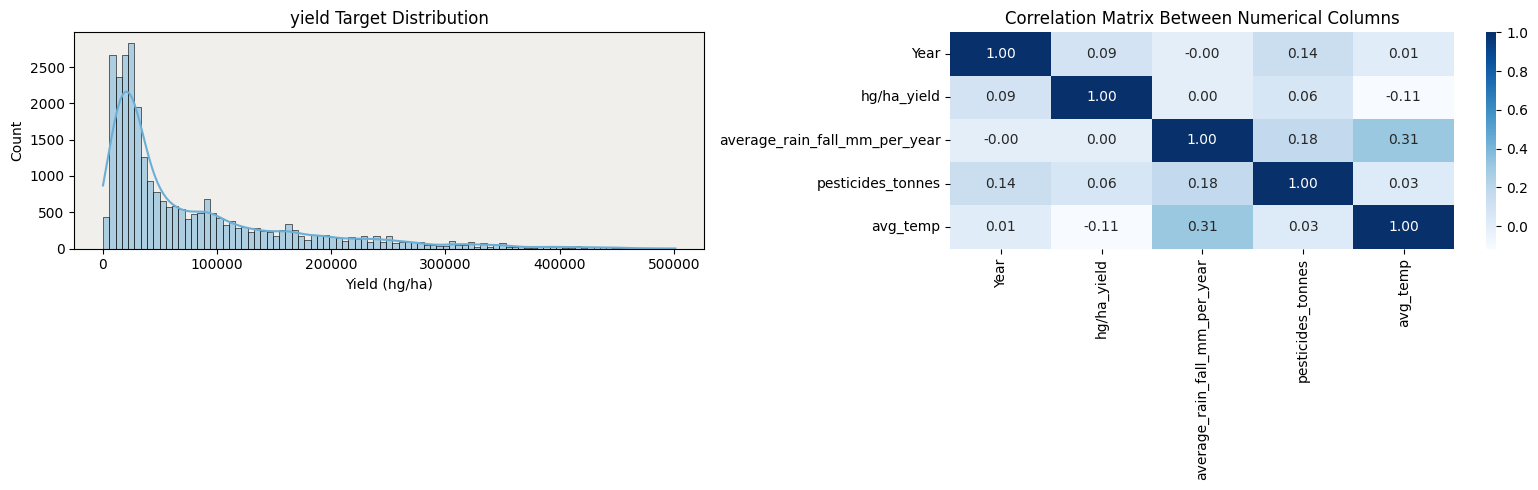

In [115]:
from matplotlib import colormaps
# Plotting Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot( df['hg/ha_yield'], kde=True,color=plt.cm.tab20c(0.07), ax=axes[0])
axes[0].set_title('yield Target Distribution')
axes[0].set_xlabel('Yield (hg/ha)')
axes[0].set_facecolor('#F0EFEB')
# Correlation Heatmap (numerical variables only)
numeric_cols = df.select_dtypes(include='number').drop(columns=['Unnamed: 0'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='Blues', fmt='.2f', ax=axes[1])
axes[1].set_title('Correlation Matrix Between Numerical Columns')
plt.tight_layout()
plt.show()

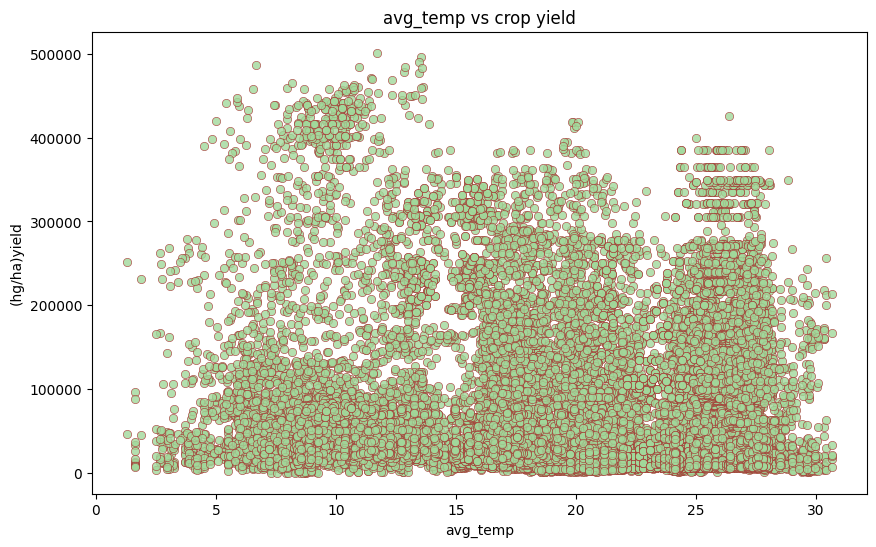

In [116]:

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='avg_temp', y='hg/ha_yield',color=plt.cm.tab20c(0.5),edgecolor='brown', alpha=0.8)
plt.title('avg_temp vs crop yield')
plt.xlabel('avg_temp')
plt.ylabel('(hg/ha)yield')
plt.show()

model

In [ ]:
X = df.drop(columns=['hg/ha_yield','Unnamed: 0'])
y = df['hg/ha_yield']

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (28242, 6)
y shape: (28242,)


In [ ]:
categorical_features = ['Area','Item']
numerical_features = ['Year','average_rain_fall_mm_per_year','pesticides_tonnes','avg_temp']

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')

Train shape: (22593, 6), Test shape: (5649, 6)


# **Model:linear regression**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [ ]:
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_lr
})

comparison.head(10)

,Actual,Predicted
0,69220,58798.515488
1,20000,15054.390788
2,51206,48662.175573
3,166986,209327.593193
4,56319,104455.367210
5,26163,47432.970433
6,30708,33415.864203
7,109771,88347.266457
8,241650,215284.397669
9,47500,88751.250986


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R²:", r2_lr)

Linear Regression
MAE: 31791.648088226717
RMSE: 50757.595231682906
R²: 0.6448235481213759


# **Model: Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

In [ ]:
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [ ]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest
MAE: 3466.6454416710926
RMSE: 9467.508855330292
R²: 0.9876429862991082


In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_rf
})

comparison.head(10)

,Actual,Predicted
0,69220,70961.50
1,20000,24360.64
2,51206,49008.01
3,166986,163303.94
4,56319,56065.67
5,26163,26212.95
6,30708,30692.22
7,109771,109805.73
8,241650,237555.11
9,47500,46007.02


In [ ]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_lr, mae_rf],
    'RMSE': [rmse_lr, rmse_rf],
    'R2': [r2_lr, r2_rf]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,31791.648088,50757.595232,0.644824
1,Random Forest,3466.645442,9467.508855,0.987643


***Lower MAE,Lower RMSE, Higher R2--
So,The best model is Random Forest***

# ***performance visualization***

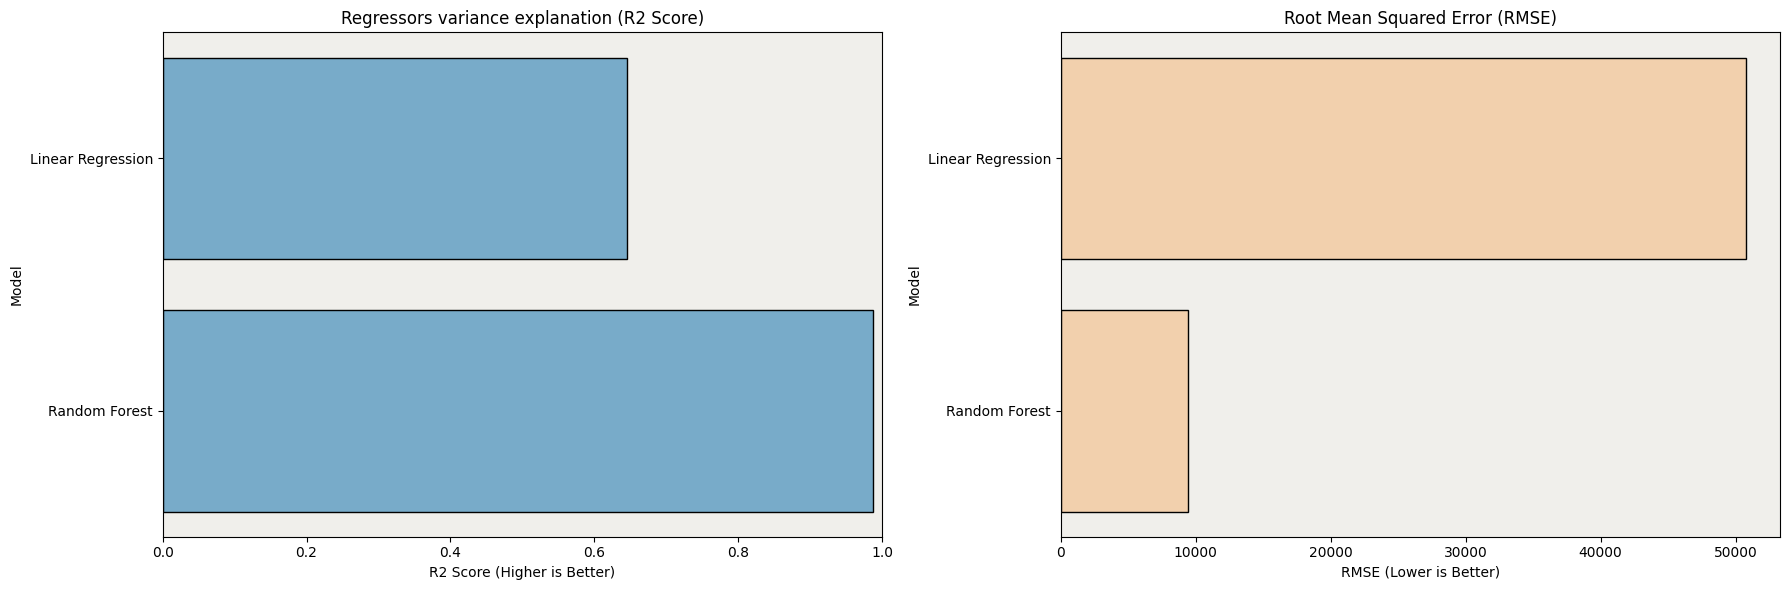

In [119]:

fig, axes = plt.subplots(1, 2, figsize=(18, 6))


sns.barplot(data = results, x='R2', y='Model',color=plt.cm.tab20c(0.07),edgecolor='k', ax=axes[0])
axes[0].set_title('Regressors variance explanation (R2 Score)')
axes[0].set_xlabel('R2 Score (Higher is Better)')
axes[0].set_xlim(0, 1.0)
axes[0].set_facecolor('#F0EFEB')

sns.barplot(data=results, x='RMSE', y='Model',color=plt.cm.tab20c(0.35),edgecolor='k', ax=axes[1])
axes[1].set_title('Root Mean Squared Error (RMSE)')
axes[1].set_xlabel('RMSE (Lower is Better)')
axes[1].set_facecolor('#F0EFEB')

plt.tight_layout()
plt.show()

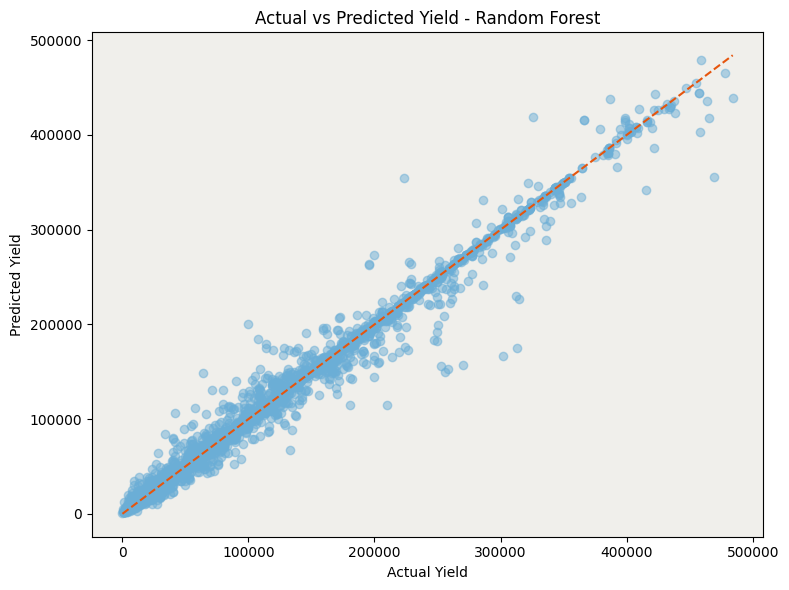

In [120]:

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(y_test, y_pred_rf,color=plt.cm.tab20c(0.07), alpha=0.5)
ax.set_facecolor('#F0EFEB')
ax.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--',color=plt.cm.tab20c(0.2)
)

ax.set_title('Actual vs Predicted Yield - Random Forest')
ax.set_xlabel('Actual Yield')
ax.set_ylabel('Predicted Yield')

plt.tight_layout()
plt.show()

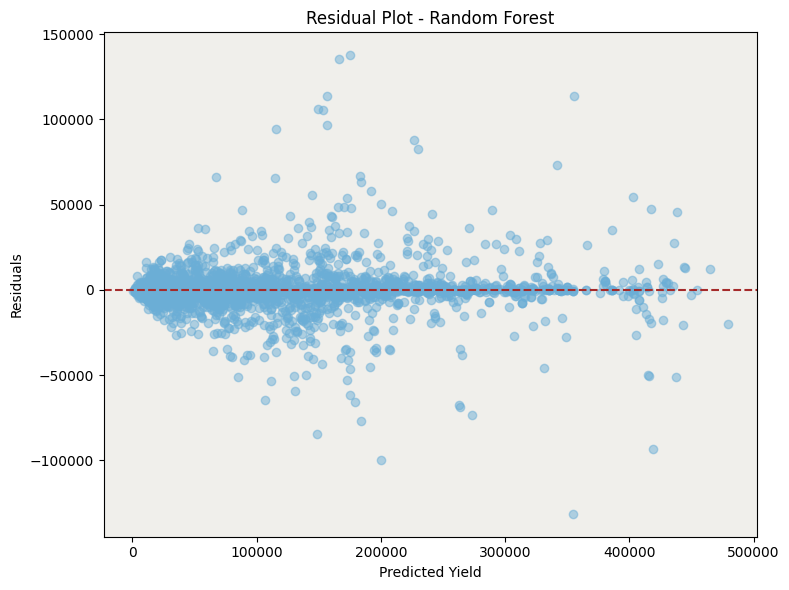

In [125]:
residuals = y_test - y_pred_rf

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_facecolor('#F0EFEB')
ax.scatter(y_pred_rf, residuals, alpha=0.5,color=plt.cm.tab20c(0.07))

ax.axhline(
    y=0,
    linestyle='--', color='brown'
)

ax.set_title('Residual Plot - Random Forest')
ax.set_xlabel('Predicted Yield')
ax.set_ylabel('Residuals')

plt.tight_layout()
plt.show()

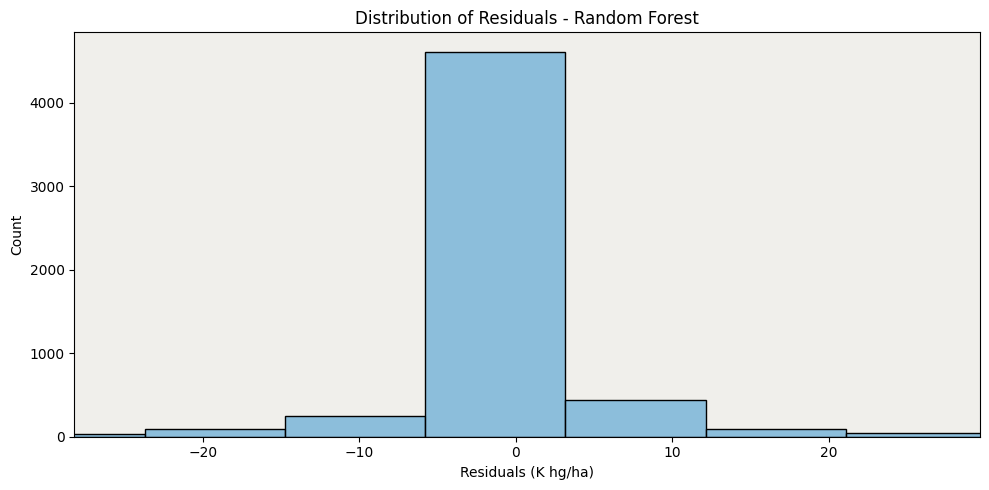

In [126]:
residuals = y_test - y_pred_rf


residuals_k = residuals / 1000


lower = residuals_k.quantile(0.01)
upper = residuals_k.quantile(0.99)


fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor('#F0EFEB')
sns.histplot(
    residuals_k,
    bins=30,
    color=plt.cm.tab20c(0.07),
    edgecolor='k',
    ax=ax
)

#ax.axvline(0,color='red',linestyle='--')

ax.set_xlim(lower, upper)

ax.set_title('Distribution of Residuals - Random Forest')
ax.set_xlabel('Residuals (K hg/ha)')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1041/2733382233.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


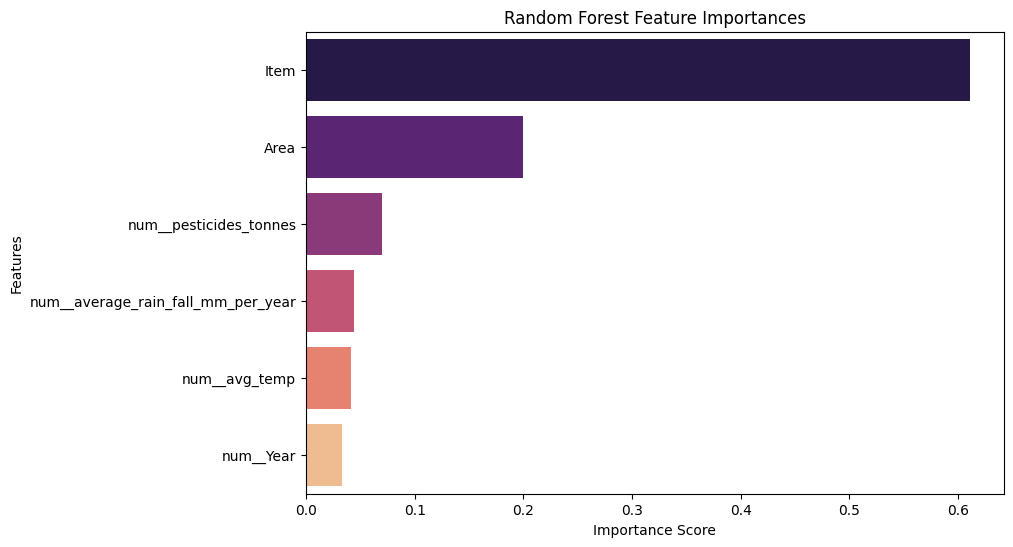

In [124]:
importances = rf_model.named_steps['model'].feature_importances_

feature_names = rf_model.named_steps[
    'preprocessor'
].get_feature_names_out()


feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})


feature_importance_df['Feature'] = (
    feature_importance_df['Feature']
    .str.replace('cat__', '', regex=False)
    .str.replace('remainder__', '', regex=False)
)


def get_original_feature(feature):
    for col in categorical_features:
        if feature.startswith(col + '_'):
            return col
    return feature

feature_importance_df['Original Feature'] = (
    feature_importance_df['Feature']
    .apply(get_original_feature)
)


grouped_importance = (
    feature_importance_df
    .groupby('Original Feature')['Importance']
    .sum()
    .reset_index()
    .sort_values('Importance', ascending=False)
)


plt.figure(figsize=(9, 6))

sns.barplot(
    data=grouped_importance,
    x='Importance',
    y='Original Feature',
    palette='magma'
)

plt.title('Random Forest Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.show()